# 03 — Teste 1: direção do próximo dias de negociação

**Target:** com os dados conhecidos ao final do dia **t**, o fechamento de **t+1** será de alta (1) ou de queda (0)?

**Teste:** usamos o mesmo Random Forest e a mesma validação temporal em duas versões. A única diferença é a inclusão do sinal criado a partir das notícias.


In [71]:
from pathlib import Path
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data/features/energy_market_news_daily.csv'
MLFLOW_DB_PATH = PROJECT_ROOT / 'mlflow.db'
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH}')
mlflow.set_experiment('next-day-direction')


<Experiment: artifact_location='/Users/hudsonborgo/Desktop/Can-AI-listen-to-the-market-improved/notebooks/mlruns/1', creation_time=1787912916584, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787912916584, lifecycle_stage='active', name='next-day-direction', tags={}, trace_location=None, workspace='default'>

In [72]:
df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date')
# Todas as janelas históricas terminam em t-1; o dia atual não entra nas médias.
df['close_ma_5_lagged'] = df['preco_fecho'].shift(1).rolling(5).mean()
df['momentum_ma_5'] = df['preco_fecho'] / df['close_ma_5_lagged'] - 1
df['volatility_5_lagged'] = df['return'].shift(1).rolling(5).std()
df['intraday_range_lag_1'] = df['intraday_range'].shift(1)
model_columns = ['return', 'momentum_ma_5', 'volatility_5_lagged', 'intraday_range_lag_1', 'high_relevance_signal_ma_2']
df = df.dropna(subset=['direction_next_day'] + model_columns).reset_index(drop=True)
df['direction_next_day'] = df['direction_next_day'].astype(int)
print(f'Observações: {len(df):,}')
print(f'Período: {df.date.min().date()} → {df.date.max().date()}')
print(f'Dias de alta: {df.direction_next_day.mean():.1%}')


Observações: 152
Período: 2026-01-12 → 2026-08-21
Dias de alta: 46.1%


In [73]:
feature_guide = pd.DataFrame([
    ('Retorno atual', 'Movimento do preço no dias de negociação t', 'Mercado'),
    ('Momentum de 5 dias de negociação', 'Distância para a média histórica, sem usar o preço futuro', 'Mercado'),
    ('Volatilidade de 5 dias de negociação', 'Risco recente, calculado até t-1', 'Mercado'),
    ('Amplitude anterior', 'Variação máxima do dias de negociação t-1', 'Mercado'),
    ('Sinal de notícias', 'Notícias relevantes suavizadas em 2 dias de negociação', 'Notícias IA'),
], columns=['Feature', 'Intuição', 'Origem'])
display(feature_guide.style.hide(axis='index').set_caption('O que o modelo enxerga'))


Feature,Intuição,Origem
Retorno atual,Movimento do preço no dias de negociação t,Mercado
Momentum de 5 dias de negociação,"Distância para a média histórica, sem usar o preço futuro",Mercado
Volatilidade de 5 dias de negociação,"Risco recente, calculado até t-1",Mercado
Amplitude anterior,Variação máxima do dias de negociação t-1,Mercado
Sinal de notícias,Notícias relevantes suavizadas em 2 dias de negociação,Notícias IA


## Hipótese e features

O preço recente fornece o contexto de mercado. A hipótese é que o sinal criado pela IA adiciona informação que ainda não está totalmente refletida nessas variáveis.

As médias e a volatilidade usam somente dados disponíveis até o momento da decisão, evitando leakage.


In [74]:
MARKET_FEATURES = ['return', 'momentum_ma_5', 'volatility_5_lagged', 'intraday_range_lag_1']
FEATURE_SETS = {
    'Somente features de mercado': MARKET_FEATURES,
    'Features de mercado + notícias IA': MARKET_FEATURES + ['high_relevance_signal_ma_2'],
}

def build_model():
    return RandomForestClassifier(
        n_estimators=500, max_depth=2, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=1,
    )


## Teste fora da amostra

A validação respeita o tempo: o modelo sempre aprende com o passado e testa em datas futuras. Internamente são quatro janelas de 30 dias de dias de negociação; na apresentação mostramos apenas o resultado agregado.


In [75]:
splitter = TimeSeriesSplit(n_splits=4, test_size=30)
metrics, predictions = [], []
for fold, (train_idx, test_idx) in enumerate(splitter.split(df), start=1):
    train, test = df.iloc[train_idx], df.iloc[test_idx]
    assert train['date'].max() < test['date'].min()
    for model_name, features in FEATURE_SETS.items():
        model = build_model()
        with mlflow.start_run(run_name=f'{model_name} - fold {fold}') as run:
            mlflow.set_tags({
                'model_type': 'RandomForestClassifier',
                'validation': 'walk-forward',
                'feature_set': model_name,
            })
            mlflow.log_params({
                'fold': fold,
                'features': ','.join(features),
                'n_features': len(features),
                'train_rows': len(train),
                'test_rows': len(test),
                'train_end': train.date.max().isoformat(),
                'test_start': test.date.min().isoformat(),
                'test_end': test.date.max().isoformat(),
                **{f'model_{key}': value for key, value in model.get_params().items()},
            })
            mlflow.log_text('\n'.join(features), f'features/{model_name}.txt')
            model.fit(train[features], train['direction_next_day'])
            predicted = model.predict(test[features])
            probability = model.predict_proba(test[features])[:, 1]
            actual = test['direction_next_day']
            fold_metrics = {
                'accuracy': accuracy_score(actual, predicted),
                'balanced_accuracy': balanced_accuracy_score(actual, predicted),
                'roc_auc': roc_auc_score(actual, probability),
            }
            mlflow.log_metrics(fold_metrics)
            metrics.append({
                'fold': fold, 'model': model_name,
                'train_end': train.date.max(), 'test_start': test.date.min(), 'test_end': test.date.max(),
                **fold_metrics,
            })
            predictions.extend({'date': d, 'fold': fold, 'model': model_name, 'actual': int(y), 'prediction': int(p), 'probability_up': float(prob)} for d, y, p, prob in zip(test.date, actual, predicted, probability))
metrics = pd.DataFrame(metrics)
predictions = pd.DataFrame(predictions)


In [76]:
summary = metrics.groupby('model').agg(
    accuracy=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    balanced_accuracy=('balanced_accuracy', 'mean'), roc_auc=('roc_auc', 'mean'),
).sort_values('accuracy')
with mlflow.start_run(run_name='walk-forward summary') as run:
    mlflow.set_tag('validation', 'walk-forward')
    mlflow.log_params({
        'n_splits': 4,
        'test_size': 30,
        'feature_sets': '; '.join(f'{name}: {", ".join(features)}' for name, features in FEATURE_SETS.items()),
    })
    metric_prefixes = {'Somente features de mercado': 'market_only', 'Features de mercado + notícias IA': 'with_news'}
    for model_name, row in summary.iterrows():
        prefix = metric_prefixes[model_name]
        mlflow.log_metrics({
            f'{prefix}_accuracy': row['accuracy'],
            f'{prefix}_accuracy_std': row['accuracy_std'],
            f'{prefix}_balanced_accuracy': row['balanced_accuracy'],
            f'{prefix}_roc_auc': row['roc_auc'],
        })
display(summary[['accuracy']].style.format({'accuracy': '{:.1%}', 'balanced_accuracy': '{:.1%}', 'roc_auc': '{:.3f}'}).set_caption('Resultado agregado fora da amostra'))


,accuracy
model,
Somente features de mercado,52.5%
Features de mercado + notícias IA,58.3%


In [77]:
registered_models = {}
for model_name, features in FEATURE_SETS.items():
    final_model = build_model()
    registry_name = 'next-day-direction-' + ('with-news' if 'notícias' in model_name else 'market-only')
    with mlflow.start_run(run_name=f'{model_name} - final registered model') as run:
        mlflow.set_tags({
            'model_type': 'RandomForestClassifier',
            'stage': 'final',
            'feature_set': model_name,
        })
        mlflow.log_params({
            'features': ','.join(features),
            'n_features': len(features),
            'training_rows': len(df),
            **{f'model_{key}': value for key, value in final_model.get_params().items()},
        })
        mlflow.log_text('\n'.join(features), 'features/feature_list.txt')
        final_model.fit(df[features], df['direction_next_day'])
        cv_metrics = summary.loc[model_name]
        mlflow.log_metrics({
            'cv_accuracy': cv_metrics['accuracy'],
            'cv_accuracy_std': cv_metrics['accuracy_std'],
            'cv_balanced_accuracy': cv_metrics['balanced_accuracy'],
            'cv_roc_auc': cv_metrics['roc_auc'],
        })
        model_info = mlflow.sklearn.log_model(
            sk_model=final_model,
            name='model',
            registered_model_name=registry_name,
        )
        registered_models[model_name] = model_info.model_uri
        print(f'Registrado: {registry_name} ({model_info.model_uri})')


2026/08/30 22:44:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'next-day-direction-market-only' already exists. Creating a new version of this model...
Created version '9' of model 'next-day-direction-market-only'.


Registrado: next-day-direction-market-only (models:/m-04f8a85ac3204c718244b0a89571b57f)


2026/08/30 22:45:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registrado: next-day-direction-with-news (models:/m-5ab8fbb2bdfc4787941ecbab246e7eb2)


Registered model 'next-day-direction-with-news' already exists. Creating a new version of this model...
Created version '9' of model 'next-day-direction-with-news'.


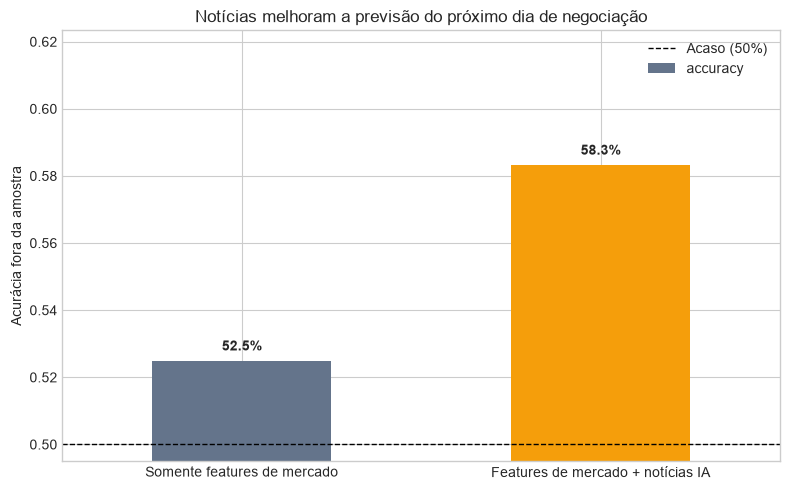

Ganho com features que vieram de notícias: +5.8% pontos percentuais


In [78]:
baseline = summary.loc['Somente features de mercado', 'accuracy']
with_news = summary.loc['Features de mercado + notícias IA', 'accuracy']
gain = with_news - baseline

ax = summary['accuracy'].plot.bar(figsize=(8, 5), color=['#64748b', '#f59e0b'], rot=0)
ax.axhline(.5, color='black', linestyle='--', linewidth=1, label='Acaso (50%)')

# Ajusta o eixo Y para começar logo abaixo do menor valor (ex: 0.48), reduzindo o espaço vertical
y_min = min(baseline, with_news) - 0.03
y_max = max(baseline, with_news) + 0.04
ax.set(ylim=(y_min, y_max), xlabel='', ylabel='Acurácia fora da amostra', title='Notícias melhoram a previsão do próximo dia de negociação')

for i, value in enumerate(summary['accuracy']): 
    # Offset menor (.003 em vez de .02) para caber no eixo truncado
    ax.text(i, value + 0.003, f'{value:.1%}', ha='center', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

print(f'Ganho com features que vieram de notícias: {gain:+.1%} pontos percentuais')

## Conclusão do teste 1

Ao incluir notícias, a acurácia sobe de **52,5% para 58,3%**: ganho de **5,8 pontos percentuais**. 

O teste sugere valor incremental das notícias para a direção do próximo dias de negociação. Como a amostra ainda é curta, tratamos o resultado como evidência inicial de que nossa hipotetse era verdadeira